# Amazon ML Challenge: Comprehensive Exploratory Data Analysis & Entity Resolution Diagnostics

This notebook implements an in-depth, production-grade exploratory data analysis for multi-source entity resolution across Source 1, Source 2, and Source 3 matched against ground truth.

### Key Analysis Sections:
1. **Setup, Configuration & Paths**
2. **Basic TSV Reader & Sample Inspection**
3. **Schema Validation**
4. **Exact Row Count (Memory-Safe)**
5. **Chunked Basic EDA (Unique IDs, Names, Addresses, Nulls, Duplicates)**
6. **Summary Statistics & Country Distribution**
7. **Text Normalization, Abbreviation Expansion & Script Detection**
8. **Token & Abbreviation Diagnostics**
9. **Address Number Extraction**
10. **Ground Truth Validation, Cardinality, Singletons & Match Patterns**
11. **Duplication & Text Length Distribution**
12. **Candidate Blocking Diagnostics & Sample Blocking Recall**
13. **Fuzzy Similarity Analysis & Ground-Truth Pair Inspection**
14. **DuckDB Direct SQL Queries**
15. **Exporting Summary Artifacts & Reports**


## 1. Imports and Configuration

In [2]:
import os
import re
import gc
import json
import math
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from tqdm.auto import tqdm
from rapidfuzz import fuzz
from unidecode import unidecode
import duckdb

# Import modular helper functions from src/eda_utils.py
import sys
sys.path.append(os.path.abspath(".."))
import src.eda_utils as eu

# ============================================================
# CONFIGURATION
# ============================================================

# Dataset paths in student_resource
BASE_DIR = os.path.join("..", "student_resource", "dataset", "train")

S1_PATH = os.path.join(BASE_DIR, "train_source1.tsv")
S2_PATH = os.path.join(BASE_DIR, "train_source2.tsv")
S3_PATH = os.path.join(BASE_DIR, "train_source3.tsv")
GT_PATH = os.path.join(BASE_DIR, "train_ground_truth.tsv")

OUTPUT_DIR = os.path.join("..", "outputs", "eda")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CHUNK_SIZE = 250_000

EXPECTED_COLUMNS = [
    "entity_id",
    "business_name",
    "business_address",
    "country"
]

GT_COLUMNS = [
    "source1_entity_id",
    "matched_entity_ids"
]

print("Configuration loaded.")
print(f"S1: {S1_PATH} (exists: {os.path.exists(S1_PATH)})")
print(f"S2: {S2_PATH} (exists: {os.path.exists(S2_PATH)})")
print(f"S3: {S3_PATH} (exists: {os.path.exists(S3_PATH)})")
print(f"GT: {GT_PATH} (exists: {os.path.exists(GT_PATH)})")
print(f"Outputs: {OUTPUT_DIR}")


Configuration loaded.
S1: ..\student_resource\dataset\train\train_source1.tsv (exists: True)
S2: ..\student_resource\dataset\train\train_source2.tsv (exists: True)
S3: ..\student_resource\dataset\train\train_source3.tsv (exists: True)
GT: ..\student_resource\dataset\train\train_ground_truth.tsv (exists: True)
Outputs: ..\outputs\eda


## 2. Basic TSV Reader & Sample Inspection

In [3]:
s1_sample = eu.read_source_sample(S1_PATH)
s2_sample = eu.read_source_sample(S2_PATH)
s3_sample = eu.read_source_sample(S3_PATH)
gt_sample = eu.read_ground_truth_sample(GT_PATH)

print("Source 1 Sample:")
display(s1_sample.head())

print("Source 2 Sample:")
display(s2_sample.head())

print("Source 3 Sample:")
display(s3_sample.head())

print("Ground Truth Sample:")
display(gt_sample.head())


Source 1 Sample:


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


Source 2 Sample:


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US


Source 3 Sample:


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,<NA>,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India


Ground Truth Sample:


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


## 3. Schema Validation

In [4]:
eu.validate_schema(S1_PATH, EXPECTED_COLUMNS, "SOURCE 1")
eu.validate_schema(S2_PATH, EXPECTED_COLUMNS, "SOURCE 2")
eu.validate_schema(S3_PATH, EXPECTED_COLUMNS, "SOURCE 3")
eu.validate_schema(GT_PATH, GT_COLUMNS, "GROUND TRUTH")



SOURCE 1
Columns:
['entity_id', 'business_name', 'business_address', 'country']
Missing columns: None
Extra columns: None

SOURCE 2
Columns:
['entity_id', 'business_name', 'business_address', 'country']
Missing columns: None
Extra columns: None

SOURCE 3
Columns:
['entity_id', 'business_name', 'business_address', 'country']
Missing columns: None
Extra columns: None

GROUND TRUTH
Columns:
['source1_entity_id', 'matched_entity_ids']
Missing columns: None
Extra columns: None


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


## 4. Exact Row Count Without Loading Full Files Into Memory

In [5]:
source_paths = {
    "S1": S1_PATH,
    "S2": S2_PATH,
    "S3": S3_PATH,
    "GT": GT_PATH
}

row_counts = {}

for name, path in source_paths.items():
    count = eu.count_rows_tsv(path)
    row_counts[name] = count
    print(f"{name}: {count:,}")

print("\nTotal source records:")
print(f"{row_counts['S1'] + row_counts['S2'] + row_counts['S3']:,}")


S1: 2,206,821
S2: 5,034,616
S3: 5,285,603
GT: 2,206,821

Total source records:
12,527,040


## 5. Chunked Basic EDA (Streaming Chunk Processing)

In [6]:
s1_stats = eu.basic_eda_chunked(S1_PATH, "S1", CHUNK_SIZE)
s2_stats = eu.basic_eda_chunked(S2_PATH, "S2", CHUNK_SIZE)
s3_stats = eu.basic_eda_chunked(S3_PATH, "S3", CHUNK_SIZE)


EDA S1: 0it [00:00, ?it/s]

EDA S2: 0it [00:00, ?it/s]

EDA S3: 0it [00:00, ?it/s]

## 6. Summary Statistics Printout

In [7]:
eu.print_eda_summary(s1_stats)
eu.print_eda_summary(s2_stats)
eu.print_eda_summary(s3_stats)



S1
Rows                  : 2,206,821
Unique entity IDs     : 2,206,821
Unique business names : 1,539,229
Unique addresses      : 2,130,606

Nulls:
  entity_id           : 0
  business_name       : 0
  business_address    : 0
  country             : 0

Countries:
  US                  : 1,323,633
  India               : 883,188

Duplicate rows caused by repeated names:
  667,592

Duplicate rows caused by repeated addresses:
  76,215

Name length:
  min       : 3.00
  max       : 105.00
  mean      : 24.03
  median    : 24.00
  p95       : 37.00
  p99       : 42.00

Address length:
  min       : 11.00
  max       : 256.00
  mean      : 52.07
  median    : 41.00
  p95       : 103.00
  p99       : 124.00

Top 20 business names:
       253 | Primary Care Group
       251 | Ear Nose & Throat Group
       222 | Pediatric Group
       220 | Womens Health Group
       218 | Physical Therapy Group
       216 | Pediatric Dental Group
       215 | Behavioral Health Group
       209 | Chiropractic

## 7. Country Distribution & Hard Blocking Potential

,S1,S2,S3
US,1323633,3016817,3170056
India,883188,2017799,2115547


<Figure size 1000x500 with 0 Axes>

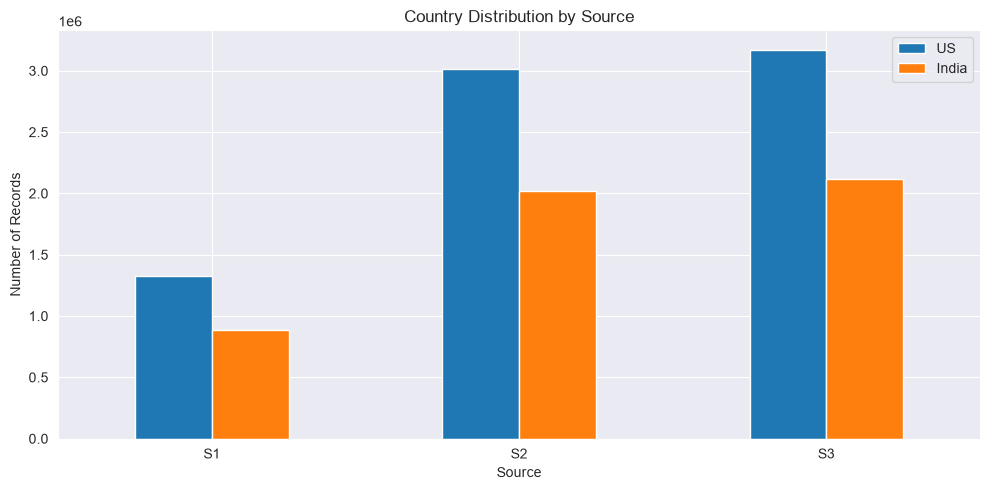

In [8]:
country_table = pd.DataFrame({
    "S1": dict(s1_stats["countries"]),
    "S2": dict(s2_stats["countries"]),
    "S3": dict(s3_stats["countries"]),
}).fillna(0).astype(int)

display(country_table)

plt.figure(figsize=(10, 5))
country_table.T.plot(kind="bar", figsize=(10, 5))
plt.title("Country Distribution by Source")
plt.xlabel("Source")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Null Value Analysis

In [9]:
print("Source 1 Nulls:")
display(eu.null_percentage(s1_stats))

print("Source 2 Nulls:")
display(eu.null_percentage(s2_stats))

print("Source 3 Nulls:")
display(eu.null_percentage(s3_stats))


Source 1 Nulls:


,column,null_count,null_percent
0,entity_id,0,0.0
1,business_name,0,0.0
2,business_address,0,0.0
3,country,0,0.0


Source 2 Nulls:


,column,null_count,null_percent
0,entity_id,0,0.000000
1,business_name,2,0.000040
2,business_address,168967,3.356105
3,country,0,0.000000


Source 3 Nulls:


,column,null_count,null_percent
0,entity_id,0,0.000000
1,business_name,13,0.000246
2,business_address,175916,3.328211
3,country,0,0.000000


## 9. Text Normalization, Unicode Cleaning & Abbreviation Expansion

In [10]:
test_records = [
    (
        "Acme Robotics Pvt Ltd",
        "42 MG Rd, Bengaluru 560001"
    ),
    (
        "Dermatology Global Specialists LLC",
        "Omaha, NE, 2214 Grand Avenue"
    ),
    (
        "इंडो फूड",
        "PLOT 71 D/2, OMKARESHWAR SOCIETY, BORIVALI WEST, MUMBAI"
    ),
    (
        "Ambika Ienal Limited",
        "Nagarbhavi, ಕರ್ನಾಟಕ"
    )
]

for name, address in test_records:
    raw = eu.merged_text(name, address)
    print("\nRAW:", raw)
    print("NORMALIZED:", eu.normalize_text(raw))
    print("EXPANDED:", eu.expand_abbreviations(raw))
    print("TRANSLITERATED:", eu.transliterate_text(raw))
    print("-" * 80)



RAW: Acme Robotics Pvt Ltd 42 MG Rd, Bengaluru 560001
NORMALIZED: acme robotics pvt ltd 42 mg rd bengaluru 560001
EXPANDED: acme robotics private limited 42 mg road bengaluru 560001
TRANSLITERATED: Acme Robotics Pvt Ltd 42 MG Rd, Bengaluru 560001
--------------------------------------------------------------------------------

RAW: Dermatology Global Specialists LLC Omaha, NE, 2214 Grand Avenue
NORMALIZED: dermatology global specialists llc omaha ne 2214 grand avenue
EXPANDED: dermatology global specialists limited liability company omaha ne 2214 grand avenue
TRANSLITERATED: Dermatology Global Specialists LLC Omaha, NE, 2214 Grand Avenue
--------------------------------------------------------------------------------

RAW: इंडो फूड PLOT 71 D/2, OMKARESHWAR SOCIETY, BORIVALI WEST, MUMBAI
NORMALIZED: इ ड फ ड plot 71 d 2 omkareshwar society borivali west mumbai
EXPANDED: इ ड फ ड plot 71 d 2 omkareshwar society borivali west mumbai
TRANSLITERATED: iNddo phuudd PLOT 71 D/2, OMKARESHWAR SOC

## 10. Script Detection Diagnostics

In [11]:
examples = [
    "Acme Robotics Pvt Ltd",
    "इंडो फूड",
    "ಕರ್ನಾಟಕ",
    "తెలుగు",
    "தமிழ்",
    "Acme ಕರ್ನಾಟಕ",
]

for x in examples:
    print(f"{x:40} -> {eu.detect_script(x)}")


Acme Robotics Pvt Ltd                    -> LATIN
इंडो फूड                                 -> DEVANAGARI
ಕರ್ನಾಟಕ                                  -> KANNADA
తెలుగు                                   -> TELUGU
தமிழ்                                    -> TAMIL
Acme ಕರ್ನಾಟಕ                             -> MIXED


## 11. Script Distribution on Full Dataset

In [12]:
s1_scripts = eu.script_distribution(S1_PATH, "S1", CHUNK_SIZE)
s2_scripts = eu.script_distribution(S2_PATH, "S2", CHUNK_SIZE)
s3_scripts = eu.script_distribution(S3_PATH, "S3", CHUNK_SIZE)

print("S1 Scripts:")
display(s1_scripts)

print("S2 Scripts:")
display(s2_scripts)

print("S3 Scripts:")
display(s3_scripts)


Script analysis S1: 0it [00:00, ?it/s]

Script analysis S2: 0it [00:00, ?it/s]

Script analysis S3: 0it [00:00, ?it/s]

S1 Scripts:


,script,count,percent
0,LATIN,4413642,100.0


S2 Scripts:


,script,count,percent
1,LATIN,8948202,88.866778
8,MIXED,496107,4.926960
0,DEVANAGARI,258863,2.570832
11,EMPTY,169164,1.680009
6,TELUGU,37799,0.375391
4,KANNADA,35787,0.355409
2,TAMIL,32440,0.322170
3,GUJARATI,29700,0.294958
5,BENGALI,29497,0.292942
7,MALAYALAM,18062,0.179378


S3 Scripts:


,script,count,percent
0,LATIN,9640551,91.196321
1,MIXED,510585,4.829960
11,EMPTY,176353,1.668239
3,DEVANAGARI,138233,1.307637
9,TELUGU,20093,0.190073
5,KANNADA,19263,0.182221
6,TAMIL,17358,0.164201
7,BENGALI,15864,0.150068
4,GUJARATI,15755,0.149037
2,MALAYALAM,9763,0.092355


## 12. Script Pair Analysis (Name vs Address) & Multilingual Examples

In [13]:
s2_script_pairs = eu.script_pair_analysis(S2_PATH, "S2", CHUNK_SIZE)
print("Top 30 Script Pairs in S2:")
display(s2_script_pairs.head(30))

s2_non_latin = eu.find_non_latin_examples(S2_PATH, n=100, chunk_size=CHUNK_SIZE)
print("Sample Non-Latin S2 Records:")
display(s2_non_latin.head(15))


Script pair S2: 0it [00:00, ?it/s]

Top 30 Script Pairs in S2:


,name_script,address_script,count,percent
1,LATIN,LATIN,4029520,80.036293
3,LATIN,MIXED,361886,7.187956
0,DEVANAGARI,LATIN,193992,3.853164
5,LATIN,EMPTY,168668,3.350166
6,DEVANAGARI,MIXED,64871,1.288499
11,TELUGU,LATIN,29825,0.592399
10,KANNADA,LATIN,27007,0.536426
2,TAMIL,LATIN,24409,0.484823
4,GUJARATI,LATIN,22291,0.442755
12,BENGALI,LATIN,22067,0.438306


Sample Non-Latin S2 Records:


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
2,S2-615967906,सन कंस्ट्रक्शंस प्राइवेट लिमिटेड,"43 SUKH SAMRUDDHI, Maharashtra, PUNE REGION, P...",India
3,S2-566688803,रियल मॉडर्न फूड लिमिटेड,"SHP NO. G-4, PLOT NO. 19, SECTOR 42, NERUL, TH...",India
4,S2-879667609,குளோபல் பிசினஸ் பிரைவேட் லிமிடெட்,"#C-21 - S, AMBATTUR, CHENNAI, Tamil Nadu",India
5,S2-348280942,શક્તિ અર્બન પ્રોડક્ટ્સ પ્રાઇવેટ લિમિટેડ,"SHOP NO.F107 AND F106, FIRST FLOOR SOHAM RESIC...",India
6,S2-64510343,अल्फा अल टेक्नोलॉजीज प्राइवेट लिमिटेड,"NO 990 C-2 GREATER KAILASH ENCLAVE PART-II, NE...",India
7,S2-631299191,ग्लोबल इन्वेस्टमेंट प्रा. लि.,"PLOT NO. ##74, SECOND FLOOR ZONE-2, M.P. NAGAR...",India
8,S2-906753214,फर्स्ट फूड प्राइवेट लिमिटेड,"HN 210 F NO 5, NASHIK, महाराष्ट्र",India
9,S2-923049280,પ્રાઇમ બાલાજી ટ્રેડિંગ પ્રા. લિ.,"B/A-5, MANINAGAR, AHMEDABAD MANINAGAR, ગુજરાત",India


## 13. Normalized Merged Text & Token Preview ("One Word Per Column" Analysis)

In [14]:
s1_demo = eu.add_text_features(s1_sample)

display(
    s1_demo[
        [
            "entity_id",
            "business_name",
            "business_address",
            "name_norm",
            "address_norm",
            "merged_norm",
            "merged_expanded",
            "merged_translit"
        ]
    ].head(20)
)

token_columns = eu.token_preview(s1_demo, "merged_norm", max_tokens=15)
print("Token Column Preview (Sample):")
display(token_columns.head(20))


,entity_id,business_name,business_address,name_norm,address_norm,merged_norm,merged_expanded,merged_translit
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",orelee s barbershop,1795 westchester drive high point nc,orelee s barbershop 1795 westchester drive hig...,orelee s barbershop 1795 westchester drive hig...,orelee s barbershop 1795 westchester drive hig...
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",prime money,17560 ellis road tahlequah ok,prime money 17560 ellis road tahlequah ok,prime money 17560 ellis road tahlequah ok,prime money 17560 ellis road tahlequah ok
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",b retail inc,1712 montebello avenue phoenix az,b retail inc 1712 montebello avenue phoenix az,b retail incorporated 1712 montebello avenue p...,b retail inc 1712 montebello avenue phoenix az
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",christ chapel,2100 cameron drive unit apartment g dundalk md,christ chapel 2100 cameron drive unit apartmen...,christ chapel 2100 cameron drive unit apartmen...,christ chapel 2100 cameron drive unit apartmen...
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",prabhav business center,797 lake town block a kolkata howrah west bengal,prabhav business center 797 lake town block a ...,prabhav business center 797 lake town block a ...,prabhav business center 797 lake town block a ...
5,S1-851869949,Custom Wealth Services LLC,"OH, Columbus, 5559 Orville Avenue",custom wealth services llc,oh columbus 5559 orville avenue,custom wealth services llc oh columbus 5559 or...,custom wealth services limited liability compa...,custom wealth services llc oh columbus 5559 or...
6,S1-785847572,Consulting Nyasa Nursing Private Limited,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",consulting nyasa nursing private limited,2505 tower 1 oakwood runwal greens mulund gore...,consulting nyasa nursing private limited 2505 ...,consulting nyasa nursing private limited 2505 ...,consulting nyasa nursing private limited 2505 ...
7,S1-27541239,Nexus Anchor Rain,"1111 Church Street, Unit 2007, Nashville, TN",nexus anchor rain,1111 church street unit 2007 nashville tn,nexus anchor rain 1111 church street unit 2007...,nexus anchor rain 1111 church street unit 2007...,nexus anchor rain 1111 church street unit 2007...
8,S1-629417405,Moore Bitwise Inc,"337 Oakland Avenue, Michigan City, IN",moore bitwise inc,337 oakland avenue michigan city in,moore bitwise inc 337 oakland avenue michigan ...,moore bitwise incorporated 337 oakland avenue ...,moore bitwise inc 337 oakland avenue michigan ...
9,S1-22305073,Dermatology Green Medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",dermatology green medicine,294 meadowcreek drive unit unit 2 village of p...,dermatology green medicine 294 meadowcreek dri...,dermatology green medicine 294 meadowcreek dri...,dermatology green medicine 294 meadowcreek dri...


Token Column Preview (Sample):


,token_1,token_2,token_3,token_4,token_5,token_6,token_7,token_8,token_9,token_10,token_11,token_12,token_13,token_14,token_15
0,orelee,s,barbershop,1795,westchester,drive,high,point,nc,,,,,,
1,prime,money,17560,ellis,road,tahlequah,ok,,,,,,,,
2,b,retail,inc,1712,montebello,avenue,phoenix,az,,,,,,,
3,christ,chapel,2100,cameron,drive,unit,apartment,g,dundalk,md,,,,,
4,prabhav,business,center,797,lake,town,block,a,kolkata,howrah,west,bengal,,,
5,custom,wealth,services,llc,oh,columbus,5559,orville,avenue,,,,,,
6,consulting,nyasa,nursing,private,limited,2505,tower,1,oakwood,runwal,greens,mulund,goreagon,link,road
7,nexus,anchor,rain,1111,church,street,unit,2007,nashville,tn,,,,,
8,moore,bitwise,inc,337,oakland,avenue,michigan,city,in,,,,,,
9,dermatology,green,medicine,294,meadowcreek,drive,unit,unit,2,village,of,pewaukee,wi,,


## 14. Global Token Statistics & Corporate/Address Abbreviations

In [15]:
s1_tokens = eu.token_statistics(S1_PATH, "S1", chunk_size=CHUNK_SIZE)
s2_tokens = eu.token_statistics(S2_PATH, "S2", chunk_size=CHUNK_SIZE)
s3_tokens = eu.token_statistics(S3_PATH, "S3", chunk_size=CHUNK_SIZE)

print("Top 50 S1 Tokens:")
display(s1_tokens.head(50))

s1_abbreviations = eu.abbreviation_frequency(S1_PATH, "S1", chunk_size=CHUNK_SIZE)
s2_abbreviations = eu.abbreviation_frequency(S2_PATH, "S2", chunk_size=CHUNK_SIZE)
s3_abbreviations = eu.abbreviation_frequency(S3_PATH, "S3", chunk_size=CHUNK_SIZE)

print("S1 Abbreviations:")
display(s1_abbreviations)

print("S2 Abbreviations:")
display(s2_abbreviations)

print("S3 Abbreviations:")
display(s3_abbreviations)


Token analysis S1: 0it [00:00, ?it/s]

Token analysis S2: 0it [00:00, ?it/s]

Token analysis S3: 0it [00:00, ?it/s]

Top 50 S1 Tokens:


,token,count
0,limited,523592
1,road,469440
2,no,447616
3,private,433618
4,llc,355745
5,delhi,330899
6,street,313332
7,inc,238332
8,drive,223040
9,unit,208370


...

,abbreviation,count
0,limited,523592
1,road,469440
2,private,433618
3,llc,355745
4,street,313332
5,inc,238332
6,drive,223040
7,avenue,190799
8,floor,163225
9,ltd,158346


S2 Abbreviations:


,abbreviation,count
0,road,684090
1,limited,534841
2,private,534401
3,llc,532396
4,ltd,420481
5,inc,403282
6,street,344928
7,st,339548
8,rd,332226
9,floor,320868


S3 Abbreviations:


,abbreviation,count
0,limited,680066
1,private,646909
2,road,631919
3,llc,575654
4,ltd,446657
5,inc,423041
6,street,364736
7,st,337663
8,rd,327402
9,dr,311071


## 15. Address Number & Numeric Entity Extraction

In [16]:
sample_addresses = [
    "F.No. 403, Road No.5, P.No.56",
    "42 MG Road, Bengaluru 560001",
    "2214 Grand Avenue, Omaha, NE"
]

for address in sample_addresses:
    print(address)
    print("Extracted numbers:", eu.extract_numbers(address))
    print()


F.No. 403, Road No.5, P.No.56
Extracted numbers: ['403', '5', '56']

42 MG Road, Bengaluru 560001
Extracted numbers: ['42', '560001']

2214 Grand Avenue, Omaha, NE
Extracted numbers: ['2214']



## 16. Ground Truth Analysis: Cardinality, Singletons, Match Distribution & ID Checks

Ground Truth Shape: (2206821, 2)
Rows: 2206821
Unique source1_entity_id: 2206821
Duplicate source1_entity_id: 0
Null source1_entity_id: 0
Null matched_entity_ids: 123247


count    2.206821e+06
mean     3.461253e+00
std      1.705323e+00
min      0.000000e+00
50%      3.000000e+00
75%      5.000000e+00
90%      6.000000e+00
95%      6.000000e+00
99%      8.000000e+00
99.9%    9.000000e+00
max      1.100000e+01
Name: match_count, dtype: float64

Singleton S1 entities : 123,247 (5.58%)
Matched S1 entities   : 2,083,574 (94.42%)


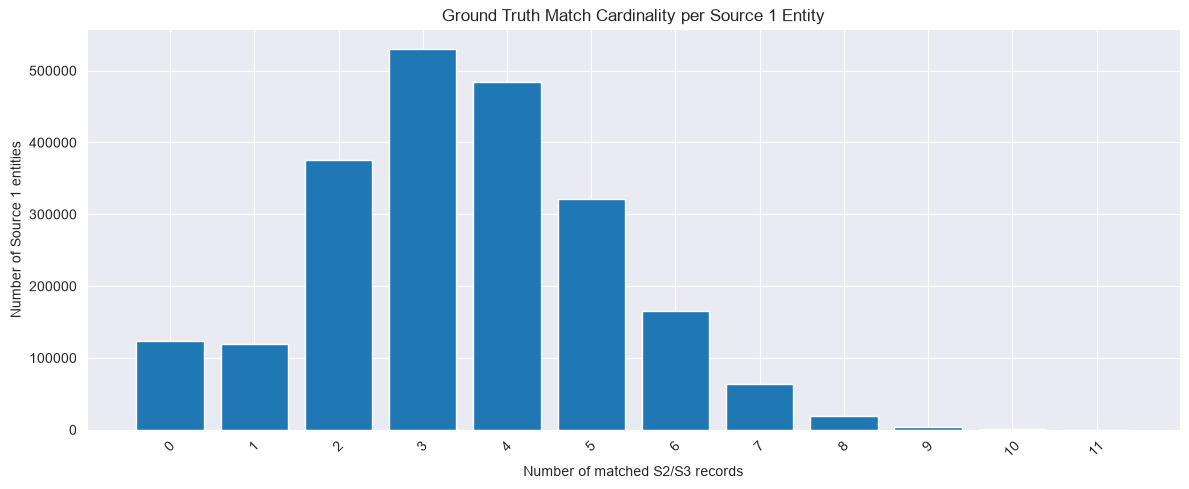

Match Source Patterns:


,pattern,count,percent
0,S2_AND_S3,1776047,80.479885
1,S3_ONLY,164498,7.454071
2,S2_ONLY,143029,6.481223
3,NONE,123247,5.584821


Rows with duplicate matched IDs: 0
Rows with invalid match ID prefix: 0
Ground truth S1 IDs not found in S1: 0


3534

In [17]:
gt = pd.read_csv(
    GT_PATH,
    sep="\t",
    dtype="string",
    usecols=["source1_entity_id", "matched_entity_ids"]
)

print("Ground Truth Shape:", gt.shape)
print("Rows:", len(gt))
print("Unique source1_entity_id:", gt["source1_entity_id"].nunique())
print("Duplicate source1_entity_id:", gt["source1_entity_id"].duplicated().sum())
print("Null source1_entity_id:", gt["source1_entity_id"].isna().sum())
print("Null matched_entity_ids:", gt["matched_entity_ids"].isna().sum())

# Match count per S1
gt["match_count"] = np.where(
    gt["matched_entity_ids"].fillna("").str.strip().eq(""),
    0,
    gt["matched_entity_ids"].fillna("").str.count(",") + 1
)

display(gt["match_count"].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99, 0.999]))

# Singletons vs matched
singleton_mask = gt["match_count"].eq(0)
singleton_count = int(singleton_mask.sum())
matched_entity_count = int((~singleton_mask).sum())

print(f"Singleton S1 entities : {singleton_count:,} ({singleton_count / len(gt) * 100:.2f}%)")
print(f"Matched S1 entities   : {matched_entity_count:,} ({matched_entity_count / len(gt) * 100:.2f}%)")

# Cardinality
cardinality = gt["match_count"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plot_cardinality = cardinality.head(30)
plt.bar(plot_cardinality.index.astype(str), plot_cardinality.values)
plt.title("Ground Truth Match Cardinality per Source 1 Entity")
plt.xlabel("Number of matched S2/S3 records")
plt.ylabel("Number of Source 1 entities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# S2 vs S3 match counts
gt["s2_match_count"] = gt["matched_entity_ids"].fillna("").str.count("S2-")
gt["s3_match_count"] = gt["matched_entity_ids"].fillna("").str.count("S3-")

gt["match_pattern"] = gt.apply(eu.classify_match_pattern, axis=1)
pattern_table = gt["match_pattern"].value_counts().rename_axis("pattern").reset_index(name="count")
pattern_table["percent"] = (pattern_table["count"] / len(gt) * 100)
print("Match Source Patterns:")
display(pattern_table)

# Duplicate IDs & prefix validation
gt["has_duplicate_match_id"] = gt["matched_entity_ids"].map(eu.has_duplicate_match_ids)
gt["valid_match_prefixes"] = gt["matched_entity_ids"].map(eu.validate_match_id_prefixes)
print("Rows with duplicate matched IDs:", gt["has_duplicate_match_id"].sum())
print("Rows with invalid match ID prefix:", (~gt["valid_match_prefixes"]).sum())

# Validate S1 IDs
s1_ids = eu.read_ids(S1_PATH)
gt_missing_s1 = ~gt["source1_entity_id"].isin(set(s1_ids))
print("Ground truth S1 IDs not found in S1:", gt_missing_s1.sum())
del s1_ids
gc.collect()


## 17. Duplicated Names/Addresses & Length Distributions

Top duplicate names in S1:


,business_name,frequency
0,Primary Care Group,253
1,Ear Nose & Throat Group,251
2,Pediatric Group,222
3,Womens Health Group,220
4,Physical Therapy Group,218
5,Pediatric Dental Group,216
6,Behavioral Health Group,215
7,Chiropractic Group,209
8,Orthopedic Group,208
9,Eye Group,207


Top duplicate addresses in S1:


,business_address,frequency
0,"108 Norle Street, College Twp, PA",14
1,"218 Phillips Street, Storm Lake, IA",13
2,"104 Roadrunner Circle, Elephant Butte, NM",13
3,"43 Franklin Street, Delaware, OH",13
4,"55, Lavkush Vihar, Singhpur, Kachhar Bithoor R...",13
5,"1921 Willow Park Drive, Fort Worth, TX",13
6,"4804 Gardenia Avenue, Glendale, AZ",12
7,"415 Northfield Boulevard, Unit A11, Murfreesbo...",12
8,"H. No. 154 - A, Veer Savarkar Nagar, Mini Bypa...",12
9,"1948 Weaver Forest Way, Morrisville, NC",12


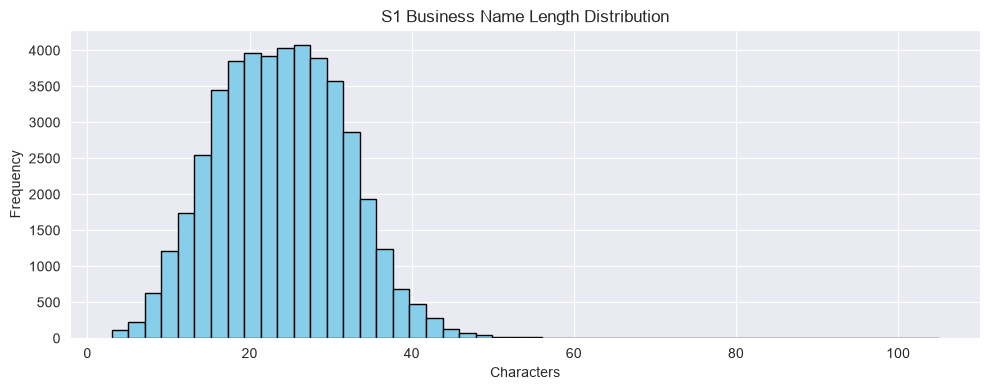

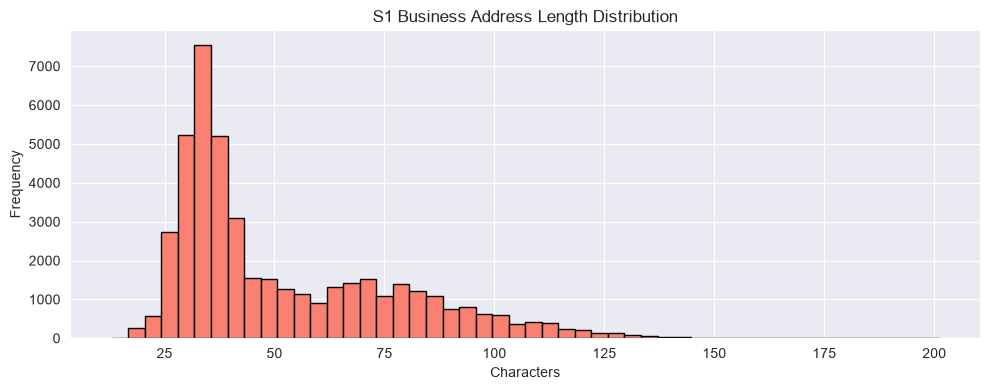

In [18]:
print("Top duplicate names in S1:")
display(eu.top_duplicate_names(s1_stats))

print("Top duplicate addresses in S1:")
display(eu.top_duplicate_addresses(s1_stats))

s1_name_len, s1_addr_len = eu.text_length_sample(S1_PATH, chunk_size=CHUNK_SIZE)

plt.figure(figsize=(10, 4))
plt.hist(s1_name_len, bins=50, color="skyblue", edgecolor="black")
plt.title("S1 Business Name Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(s1_addr_len, bins=50, color="salmon", edgecolor="black")
plt.title("S1 Business Address Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 18. Cross-Script Transliteration Inspection

In [19]:
multilingual_examples = eu.find_transliteration_examples(S2_PATH, n=100, chunk_size=CHUNK_SIZE)
print(f"Discovered {len(multilingual_examples)} multilingual / cross-script records in S2:")
display(multilingual_examples.head(20))


Discovered 100 multilingual / cross-script records in S2:


,entity_id,name,address,name_script,address_script,name_translit,address_translit
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",DEVANAGARI,LATIN,raam maarkettiNg praaivett limittedd,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi"
1,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",DEVANAGARI,LATIN,aadity proNprttiij elelpii,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh"
2,S2-615967906,सन कंस्ट्रक्शंस प्राइवेट लिमिटेड,"43 SUKH SAMRUDDHI, Maharashtra, PUNE REGION, P...",DEVANAGARI,LATIN,sn kNsttrkshNs praaivett limittedd,"43 SUKH SAMRUDDHI, Maharashtra, PUNE REGION, P..."
3,S2-566688803,रियल मॉडर्न फूड लिमिटेड,"SHP NO. G-4, PLOT NO. 19, SECTOR 42, NERUL, TH...",DEVANAGARI,LATIN,riyl moNddrn phuudd limittedd,"SHP NO. G-4, PLOT NO. 19, SECTOR 42, NERUL, TH..."
4,S2-879667609,குளோபல் பிசினஸ் பிரைவேட் லிமிடெட்,"#C-21 - S, AMBATTUR, CHENNAI, Tamil Nadu",TAMIL,LATIN,kulloopl picinnns piraiveett limittett,"#C-21 - S, AMBATTUR, CHENNAI, Tamil Nadu"
5,S2-978126813,Private Ambernath Sólar Limited,"PLOT NO B-78/1, ADDITIONAL MIDC ANAND NAGAR, A...",LATIN,MIXED,Private Ambernath Solar Limited,"PLOT NO B-78/1, ADDITIONAL MIDC ANAND NAGAR, A..."
6,S2-348280942,શક્તિ અર્બન પ્રોડક્ટ્સ પ્રાઇવેટ લિમિટેડ,"SHOP NO.F107 AND F106, FIRST FLOOR SOHAM RESIC...",GUJARATI,LATIN,shkti arbn proddktts praaivett limittedd,"SHOP NO.F107 AND F106, FIRST FLOOR SOHAM RESIC..."
7,S2-224839523,Great Estate Private Ltd,"H.NO 13 C/O:MADAN MOHAN JHA, S/O:SH AKHILESH J...",LATIN,MIXED,Great Estate Private Ltd,"H.NO 13 C/O:MADAN MOHAN JHA, S/O:SH AKHILESH J..."
8,S2-64510343,अल्फा अल टेक्नोलॉजीज प्राइवेट लिमिटेड,"NO 990 C-2 GREATER KAILASH ENCLAVE PART-II, NE...",DEVANAGARI,LATIN,alphaa al tteknoloNjiij praaivett limittedd,"NO 990 C-2 GREATER KAILASH ENCLAVE PART-II, NE..."
9,S2-631299191,ग्लोबल इन्वेस्टमेंट प्रा. लि.,"PLOT NO. ##74, SECOND FLOOR ZONE-2, M.P. NAGAR...",DEVANAGARI,MIXED,globl investtmeNtt praa. li.,"PLOT NO. ##74, SECOND FLOOR ZONE-2, M.P. NAGAR..."


## 19. Candidate Blocking Diagnostics & Block Size Analysis

In [20]:
s1_block_demo = eu.add_blocking_features(s1_demo)
display(
    s1_block_demo[
        [
            "entity_id",
            "country",
            "business_name",
            "business_address",
            "name_norm",
            "name_prefix4",
            "name_first_token",
            "postal_code",
            "country_name_prefix",
            "country_postal"
        ]
    ].head(20)
)

name_prefix_sizes_s2 = eu.block_size_analysis(
    S2_PATH,
    lambda df: df["country_name_prefix"],
    "country_name_prefix",
    chunk_size=CHUNK_SIZE
)

print("S2 Block Size Distribution (country + name_prefix4):")
display(name_prefix_sizes_s2.describe(percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]))

# Sample estimate
s2_demo2 = eu.add_blocking_features(s2_sample)
estimated_pairs = eu.estimate_pair_count_from_blocks(
    s1_block_demo["country_name_prefix"],
    s2_demo2["country_name_prefix"]
)
print("Estimated candidate pairs on 10k sample:", estimated_pairs)


,entity_id,country,business_name,business_address,name_norm,name_prefix4,name_first_token,postal_code,country_name_prefix,country_postal
0,S1-925783039,US,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",orelee s barbershop,orel,orelee,,US_orel,US_
1,S1-773889195,US,Prime Money,"17560 Ellis Road, Tahlequah, OK",prime money,prim,prime,17560,US_prim,US_17560
2,S1-377745466,US,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",b retail inc,bret,b,,US_bret,US_
3,S1-133037285,US,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",christ chapel,chri,christ,,US_chri,US_
4,S1-755362802,India,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",prabhav business center,prab,prabhav,,India_prab,India_
5,S1-851869949,US,Custom Wealth Services LLC,"OH, Columbus, 5559 Orville Avenue",custom wealth services llc,cust,custom,,US_cust,US_
6,S1-785847572,India,Consulting Nyasa Nursing Private Limited,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",consulting nyasa nursing private limited,cons,consulting,,India_cons,India_
7,S1-27541239,US,Nexus Anchor Rain,"1111 Church Street, Unit 2007, Nashville, TN",nexus anchor rain,nexu,nexus,,US_nexu,US_
8,S1-629417405,US,Moore Bitwise Inc,"337 Oakland Avenue, Michigan City, IN",moore bitwise inc,moor,moore,,US_moor,US_
9,S1-22305073,US,Dermatology Green Medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",dermatology green medicine,derm,dermatology,,US_derm,US_


Block analysis: country_name_prefix: 0it [00:00, ?it/s]

S2 Block Size Distribution (country + name_prefix4):


count    200540.000000
mean         25.105296
std        1057.939735
min           1.000000
50%           2.000000
90%          13.000000
95%          43.000000
99%         292.610000
99.9%      3606.603000
max      455759.000000
Name: block_size, dtype: float64

Estimated candidate pairs on 10k sample: 63713


## 20. Ground-Truth-Driven Blocking Recall Evaluation (Sample Benchmark)

In [25]:
recall_prefix, detail_prefix = eu.evaluate_blocking_on_sample(
    s1_sample,
    s2_sample,
    gt_sample,
    "country_name_prefix",
    "country_name_prefix"
)

print(f"Sample Blocking Recall (country + name_prefix4): {recall_prefix * 100:.2f}%")
display(detail_prefix.head(15))


Sample Blocking Recall (country + name_prefix4): 0.00%


,entity_id,true_matches,recovered,block_candidates
0,S1-447452795,2,0,23
1,S1-378978603,3,0,0
2,S1-844896591,2,0,10
3,S1-401761505,5,0,1
4,S1-966027321,5,0,0
5,S1-88817160,2,0,0
6,S1-674323954,4,0,15
7,S1-680008372,3,0,0
8,S1-354301488,4,0,10
9,S1-539879230,4,0,3


## 21. Ground-Truth Pair Inspection for Supervised Pairing

In [26]:
gt_pair_sample = gt.sample(min(100_000, len(gt)), random_state=42).copy()

gt_pair_sample["match_ids_list"] = (
    gt_pair_sample["matched_entity_ids"]
    .fillna("")
    .map(lambda x: [] if not x else x.split(","))
)

exploded_sample = (
    gt_pair_sample[["source1_entity_id", "match_ids_list"]]
    .explode("match_ids_list")
    .rename(columns={"match_ids_list": "matched_entity_id"})
    .dropna()
)

print("Exploded Ground Truth Pairs (Sample):")
display(exploded_sample.head(20))


Exploded Ground Truth Pairs (Sample):


,source1_entity_id,matched_entity_id
2195840,S1-384734976,S2-685146894
2195840,S1-384734976,S2-908470079
2195840,S1-384734976,S3-109845102
2195840,S1-384734976,S3-176459320
1487051,S1-574038342,S2-133116927
1487051,S1-574038342,S2-180265553
1487051,S1-574038342,S2-201976425
993966,S1-797774718,S2-151469064
993966,S1-797774718,S3-994706509
565428,S1-729164458,S2-619382517


## 22. RapidFuzz String Similarity Experiments

In [27]:
fuzzy_examples = [
    ("Acme Robotics Incorporated", "Acme Robotics Inc"),
    ("Acme Robotics", "Acme Robotix"),
    ("Mahatma Gandhi Road", "MG Rd")
]

for a, b in fuzzy_examples:
    print(f"A: {a}")
    print(f"B: {b}")
    print(eu.similarity_demo(a, b))
    print("-" * 50)


A: Acme Robotics Incorporated
B: Acme Robotics Inc
{'ratio': 79.06976744186046, 'partial_ratio': 100.0, 'token_sort_ratio': 79.06976744186046, 'token_set_ratio': 86.66666666666667}
--------------------------------------------------
A: Acme Robotics
B: Acme Robotix
{'ratio': 88.0, 'partial_ratio': 95.65217391304348, 'token_sort_ratio': 88.0, 'token_set_ratio': 88.0}
--------------------------------------------------
A: Mahatma Gandhi Road
B: MG Rd
{'ratio': 41.666666666666664, 'partial_ratio': 60.0, 'token_sort_ratio': 33.333333333333336, 'token_set_ratio': 33.33333333333333}
--------------------------------------------------


## 23. DuckDB SQL Analytics for Large-Scale Queries

In [28]:
con = duckdb.connect()
con.execute("PRAGMA threads=8;")
con.execute("PRAGMA memory_limit='8GB';")
print("DuckDB Version:", con.execute("SELECT version();").fetchone()[0])

# Direct SQL query on S1
s1_sql_summary = con.execute(f"""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT entity_id) AS unique_ids,
    COUNT(DISTINCT business_name) AS unique_names,
    COUNT(DISTINCT business_address) AS unique_addresses,
    COUNT(DISTINCT country) AS countries
FROM read_csv(
    '{S1_PATH.replace(os.sep, '/')}',
    delim='\t',
    header=true,
    auto_detect=true
);
""").df()

display(s1_sql_summary)

# S2 Country breakdown via DuckDB
s2_sql_countries = con.execute(f"""
SELECT
    country,
    COUNT(*) AS records,
    COUNT(DISTINCT business_name) AS unique_names,
    COUNT(DISTINCT business_address) AS unique_addresses
FROM read_csv(
    '{S2_PATH.replace(os.sep, '/')}',
    delim='\t',
    header=true,
    auto_detect=true
)
GROUP BY country
ORDER BY records DESC;
""").df()

display(s2_sql_countries)


DuckDB Version: v1.4.0


,rows,unique_ids,unique_names,unique_addresses,countries
0,2206821,2206821,1539229,2130606,2


,country,records,unique_names,unique_addresses
0,US,3016817,2721444,2578974
1,India,2017799,1685529,1758287


## 24. Export Analysis Results & Summary Report

In [29]:
s1_scripts.to_csv(os.path.join(OUTPUT_DIR, "s1_script_distribution.csv"), index=False)
s2_scripts.to_csv(os.path.join(OUTPUT_DIR, "s2_script_distribution.csv"), index=False)
s3_scripts.to_csv(os.path.join(OUTPUT_DIR, "s3_script_distribution.csv"), index=False)

s1_tokens.to_csv(os.path.join(OUTPUT_DIR, "s1_top_tokens.csv"), index=False)
s2_tokens.to_csv(os.path.join(OUTPUT_DIR, "s2_top_tokens.csv"), index=False)
s3_tokens.to_csv(os.path.join(OUTPUT_DIR, "s3_top_tokens.csv"), index=False)

s1_abbreviations.to_csv(os.path.join(OUTPUT_DIR, "s1_abbreviations.csv"), index=False)
s2_abbreviations.to_csv(os.path.join(OUTPUT_DIR, "s2_abbreviations.csv"), index=False)
s3_abbreviations.to_csv(os.path.join(OUTPUT_DIR, "s3_abbreviations.csv"), index=False)

pattern_table.to_csv(os.path.join(OUTPUT_DIR, "ground_truth_match_patterns.csv"), index=False)
cardinality.to_csv(os.path.join(OUTPUT_DIR, "ground_truth_cardinality.csv"))

summary = {
    "s1_records": int(row_counts["S1"]),
    "s2_records": int(row_counts["S2"]),
    "s3_records": int(row_counts["S3"]),
    "total_source_records": int(row_counts["S1"] + row_counts["S2"] + row_counts["S3"]),
    "ground_truth_records": int(len(gt)),
    "s1_singletons": int((gt["match_count"] == 0).sum()),
    "s1_with_matches": int((gt["match_count"] > 0).sum()),
    "singleton_percentage": float((gt["match_count"] == 0).mean() * 100),
    "mean_matches_per_s1": float(gt["match_count"].mean()),
    "median_matches_per_s1": float(gt["match_count"].median()),
    "max_matches_per_s1": int(gt["match_count"].max()),
    "s2_only_entities": int((gt["match_pattern"] == "S2_ONLY").sum()),
    "s3_only_entities": int((gt["match_pattern"] == "S3_ONLY").sum()),
    "both_sources_entities": int((gt["match_pattern"] == "S2_AND_S3").sum()),
}

print(json.dumps(summary, indent=4))

with open(os.path.join(OUTPUT_DIR, "summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

print(f"\nAll EDA outputs successfully saved to: {OUTPUT_DIR}")


{
    "s1_records": 2206821,
    "s2_records": 5034616,
    "s3_records": 5285603,
    "total_source_records": 12527040,
    "ground_truth_records": 2206821,
    "s1_singletons": 123247,
    "s1_with_matches": 2083574,
    "singleton_percentage": 5.584820880352326,
    "mean_matches_per_s1": 3.4612526344456573,
    "median_matches_per_s1": 3.0,
    "max_matches_per_s1": 11,
    "s2_only_entities": 143029,
    "s3_only_entities": 164498,
    "both_sources_entities": 1776047
}

All EDA outputs successfully saved to: ..\outputs\eda
